# Delay and sum beamforming
If more than one microphone is available, the recorded signals of the microphones can be combined in order to increase the [SNR](../Basics/SignalToNoiseRatio.ipynb) of the recording. Examples for algorithms that are utilizing several receivers are called MIMO (multiple input multiple output) or beamforming.

In the following, the simplest algorithm for several receivers/sensors is introduced: the delay and sum beamformer as explained in the book <cite>Microphone Arrays from M. Brandstein et. al</cite>.

## Spatial Setup
In the following, a setup with two microphones and a single sound source at a random position is assumed:

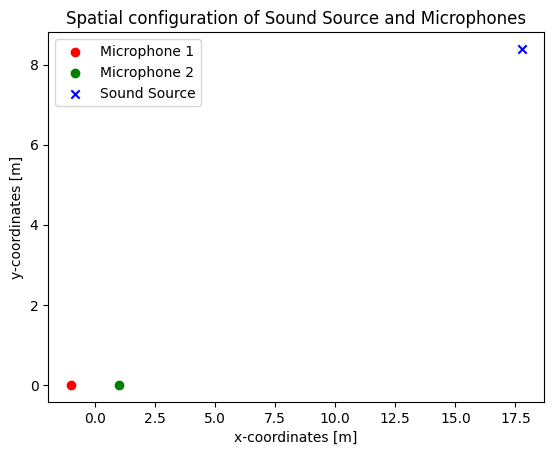

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import wave

# The microphone array has a fixed (known) positioning
CoordinateMicrophone1 = np.array([-1,0])
CoordinateMicrophone2 = np.array([ 1,0])

# the sound source has a random positioning
RandomCoordinatesOfSoundSource = 10*np.random.randn(2)

plt.scatter(CoordinateMicrophone1[0], CoordinateMicrophone1[1], marker='o', color='red')
plt.scatter(CoordinateMicrophone2[0], CoordinateMicrophone2[1], marker='o', color='green')
plt.scatter(RandomCoordinatesOfSoundSource[0], RandomCoordinatesOfSoundSource[1], marker='x', color='blue')
plt.legend(['Microphone 1', 'Microphone 2', 'Sound Source'])
plt.xlabel('x-coordinates [m]')
plt.ylabel('y-coordinates [m]')
plt.title('Spatial configuration of Sound Source and Microphones')
plt.show()

## Channel model
The audio signal $x(n)$ is sent out in all directions evenly. This corresponds to the model of a point source.
The microphones record an audio signal with a certain [SNR](../Basics/SignalToNoiseRatio.ipynb). The background noise of each recording/each microphone is assumed to be statistical independent [additive white Gaussian noise](../Basics/AdditiveWhiteGaussianNoise.ipynb).

In [44]:
def ReadWaveAsNumpyArray(Filename):
    """Reads a wave file and returns the audio data as a numpy array along with the sample rate.

    Args:
        Filename (str): Path to the wave file.

    Returns:
        tuple: A tuple containing:
            - numpy.ndarray: The audio data as a numpy array.
            - int: The sample rate of the audio data.
    """
    with wave.open(Filename, 'rb') as wf:
        num_channels = wf.getnchannels()
        sample_width = wf.getsampwidth()
        sample_rate = wf.getframerate()
        num_frames = wf.getnframes()

        raw_data = wf.readframes(num_frames)

        if sample_width == 1:
            dtype = np.uint8  # 8-bit PCM
        elif sample_width == 2:
            dtype = np.int16  # 16-bit PCM
        elif sample_width == 4:
            dtype = np.int32  # 32-bit PCM
        else:
            raise ValueError(f"Unsupported sample width: {sample_width}")

        audio_data = np.frombuffer(raw_data, dtype=dtype) / (2**(8 * sample_width - 1) - 1)

        if num_channels > 1:
            audio_data = audio_data.reshape(-1, num_channels)
            # extract first channel only
            audio_data = audio_data[:, 0]
    return audio_data, sample_rate

x, r = ReadWaveAsNumpyArray('../Audio/PferdeSchnaubenNichtDieNase.wav')

NoiseGain = 1e-2
NoiseOfMic1 = np.random.randn(len(x)) * NoiseGain
NoiseOfMic2 = np.random.randn(len(x)) * NoiseGain

y1 = x + NoiseOfMic1
y2 = x + NoiseOfMic2

def SNR(x, y):
    return 10*np.log10(np.sum(x**2)/np.sum((x-y)**2))

print('SNR of mic1:', SNR(x, y1))
print('SNR of mic2:', SNR(x, y2))

SNR of mic1: 19.239202245042893
SNR of mic2: 19.26852112484348


Additionally, the distances between the sound source and the microphones lead to delays in the recordings $y_1(n)$ and $y_2(n)$, which is simulated in the following:

- The position in 2D space of the microphone is $\left(m_x, m_y\right)$.
- The position in 2D space of the sound source is $\left(s_x, s_y\right)$.
- The distance between two positions is evaluated by the Euclidean distance: $\text{dist}=\sqrt{\left(m_x-s_x\right)^2 + \left(m_y-s_y\right)^2}$.
- The delay $T_\text{seconds}$ is evaluated by the speed of sound $c=343$ m/s: $T_\text{seconds}=\frac{\text{dist}}{c}$.
- The delay in samples is evaluated by the sampling rate $r$: $T=\text{round}\left(T_\text{seconds}\cdot r\right)$ 

In [45]:
# Euclidean distance
Distance1 = np.sqrt((RandomCoordinatesOfSoundSource[0] - CoordinateMicrophone1[0])**2 + (RandomCoordinatesOfSoundSource[1] - CoordinateMicrophone1[1])**2)
Distance2 = np.sqrt((RandomCoordinatesOfSoundSource[0] - CoordinateMicrophone2[0])**2 + (RandomCoordinatesOfSoundSource[1] - CoordinateMicrophone2[1])**2)

print('Distance between sound source and microphone 1:', Distance1, ' m')
print('Distance between sound source and microphone 2:', Distance2, ' m')

SpeedOfSound = 343 # meter per second at 20°C
Delay11 = int(Distance1 / SpeedOfSound * r) # delay in samples from source 1 to sink 1
Delay21 = int(Distance2 / SpeedOfSound * r) # delay in samples from source 1 to sink 2
print('Delay of microphone 1:', Delay11, ' samples')
print('Delay of microphone 2:', Delay21, ' samples')
# roll is a very simple approximation of delayed signals. In real world recordings, the last samples are not inserted at the beginning
y1 = np.roll(y1, Delay11)
y2 = np.roll(y2, Delay21)

Distance between sound source and microphone 1: 20.54607712671506  m
Distance between sound source and microphone 2: 18.73830868515705  m
Delay of microphone 1: 1320  samples
Delay of microphone 2: 1204  samples


## Evaluation of the delay
It is possible to estimate the delay between two signals by the following algorithm:

a) Evaluate the [cross correlation](../Basics/CrossCorrelation.ipynb) $\varphi(m)$ between the two recordings $y_1(n)$ and $y_2(n)$, by $\varphi(m)=\sum_{n=0}^{N-1} y_1(n)\cdot y_2(n+m)$.

b) The delay in samples corresponds to the position $T$ of the maximum of $\varphi(m)$.

c) If the delay $T$ is larger than $\frac{N}{2}$, a negative delay is measured: $T\leftarrow T - N$.

In [46]:
def EvaluateCrossCorrelation(s, g):
    FFTLen = 2*np.maximum(s.shape[0], g.shape[0])
    return np.fft.ifft(np.fft.fft(g, n=FFTLen) * np.conj(np.fft.fft(s, n=FFTLen))).real

def EvaluateDelay(x, y):
    phi = EvaluateCrossCorrelation(x, y)
    FFTLen = phi.shape[0]
    Delay = np.argmax(phi)
    if Delay > FFTLen/2:
        Delay -= FFTLen
    return Delay

# test the delay evaluation  
MaxDelayToTest = 10000
Delay = np.random.randint(MaxDelayToTest) - MaxDelayToTest//2
y = np.roll(x, Delay) # y is delayed by Delay samples
assert EvaluateDelay(x, y) == Delay, 'wrong delay evaluation'

## Delay and sum beamforming algorithm
After evaluating the delay, the microphones signals are aligned over the time-axis in order to maximize the correlation between both signals by rolling one of the signals by the evaluated delay.
Finally, the sum signal of the time-aligned signals is evaluated by taking the mean value of both signals.

The wanted signal from the sound source is perfectly aligned in the sum signal. Therefore, the power of the wanted signal is four times larger in the sum signal compared to the single microphone signals.
The noise signals are assumed to be uncorrelated. If you add up two uncorrelated signals, their power is simply added. Therefore, the power of the noise is only two times larger. By this, the SNR increases by roughly $3$ dB:

$\text{SNR}=10\log_{10}\frac{4}{2}=3.01$ dB

In [47]:
def CompensateDelay(y1, y2):
    EstimatedDelay = EvaluateDelay(y1, y2)
    if EstimatedDelay > 0:
        y1 = np.roll(y1, EstimatedDelay)
    else:
        y2 = np.roll(y2, -EstimatedDelay)
    return y1, y2

def DelayAndSumBeamformer(y1, y2):
    y1, y2 = CompensateDelay(y1, y2)
    return 0.5 * y1 + 0.5 * y2

print('SNR after beamforming: ', SNR(np.roll(x, np.maximum(Delay11, Delay21)), DelayAndSumBeamformer(y1, y2)))

SNR after beamforming:  22.249451406631472


## Normalized correlation and orthogonality
Due to the proposed delay and sum beamformer, the SNR of the recording increases by roughly 3 dB in the case of two microphones. This gain is based on the fact, that the noise of the two microphones is uncorrelated and the wanted signal $x(n)$ in both recordings is highly correlated.

Correlation can be evaluated by the following steps:

1) Evaluate the cross correlation $\varphi(m)$ between two signals $s(n)$ and $g(n)$.

2) Take the maximum absolute value of $\varphi(m)$ and normalize it to $\sqrt{\sum_n s^2(n) \cdot \sum_n g^2(n)}$.

The result is called the normalized cross correlation coefficient $\varphi_{\text{norm}}$. The normalized cross correlation coefficient is limited to the range $0\leq\left|\varphi_{\text{norm}}\right|\leq 1$. A value of $\varphi_{\text{norm}}\approx 1$ corresponds to high correlation. A value of $\varphi_{\text{norm}}\approx 0$ means, that both signals $s(n)$ and $g(n)$ are nearly uncorrelated. In this case, both signals are also called orthogonal. 

In [48]:
def EvaluateNormalizedCorrelation(s, g):
    phi = EvaluateCrossCorrelation(s, g)
    return np.max(np.abs(phi)) / np.sqrt(np.sum(s**2) * np.sum(g**2))

phi1 = EvaluateNormalizedCorrelation(NoiseOfMic1, NoiseOfMic2)
phi2 = EvaluateNormalizedCorrelation(y1, y2)
print('Normalized correlation of noise signals:', phi1)
print('Normalized correlation of recorded signals:', phi2)

Normalized correlation of noise signals: 0.018057740343539196
Normalized correlation of recorded signals: 0.9883172677215449


## Programming exercise
So far, the channel model between the both recorded signals is: $y_2(n) \approx y_1(n-T)$.
Extend the model, such that also a damping is possible: $y_2(n) \approx a\cdot y_1(n-T)$.

For this, find the $a$ minimizing the following error:

$\text{error}=\sum_n\left(a\cdot y_1(n-T) - y_2(n)\right)^2$

This can be done by the following steps:

1) Evaluate the derivative $\frac{d\text{error}}{da}$.

2) Set the derivative to zero.

3) Solve for $a$.

In [49]:
def EvaluateGainForChannels(y1, y2):
    a = 1.0
    ### solution begins
    z1, z2 = CompensateDelay(y1, y2)
    a = np.sum(z1 * z2) / np.sum(z1**2)
    ### solution ends
    return a

def DelayAndSumBeamformerGainCompensated(y1, y2):
    z = 0.0
    ### solution begins
    a = EvaluateGainForChannels(y1, y2)
    z = DelayAndSumBeamformer(y1, y2 / a)
    ### solution ends
    return z

import unittest

class TestProgrammingExercise(unittest.TestCase):

    def __CreateTestSignals(self, a):
        y1 = 1 * x + NoiseOfMic1
        y2 = a * x + NoiseOfMic2
        y1 = np.roll(y1, Delay11)
        y2 = np.roll(y2, Delay21)
        return y1, y2

    def test_Gain(self):
        a = np.random.rand(1) + 0.5
        y1, y2 = self.__CreateTestSignals(a)
        a_est = EvaluateGainForChannels(y1, y2)
        self.assertAlmostEqual(a, a_est, delta = 0.05)
                               
    def test_SNRIncreasingLargeA(self):
        y1, y2 = self.__CreateTestSignals(a = 1.0)
        z = DelayAndSumBeamformer(y1, y2)
        SNR1 = SNR(np.roll(x, np.maximum(Delay11, Delay21)), z)
        a = np.random.rand(1) + 3.0
        y1, y2 = self.__CreateTestSignals(a)
        z = DelayAndSumBeamformerGainCompensated(y1, y2)
        SNR2 = SNR(np.roll(x, np.maximum(Delay11, Delay21)), z)
        self.assertGreater(SNR2, SNR1)

    def test_SNRIncreasingSmallA(self):
        y1, y2 = self.__CreateTestSignals(a = 1.0)
        z = DelayAndSumBeamformer(y1, y2)
        SNR1 = SNR(np.roll(x, np.maximum(Delay11, Delay21)), z)
        a = 1/(np.random.rand(1) + 3.0)
        y1, y2 = self.__CreateTestSignals(a)
        z = DelayAndSumBeamformerGainCompensated(y1, y2)
        SNR2 = SNR(np.roll(x, np.maximum(Delay11, Delay21)), z)
        self.assertGreater(SNR2, SNR1 + 20*np.log10(a))

unittest.main(argv=[''], verbosity=2, exit=False)

test_Gain (__main__.TestProgrammingExercise.test_Gain) ... ok
test_SNRIncreasingLargeA (__main__.TestProgrammingExercise.test_SNRIncreasingLargeA) ... ok
test_SNRIncreasingSmallA (__main__.TestProgrammingExercise.test_SNRIncreasingSmallA) ... ok

----------------------------------------------------------------------
Ran 3 tests in 0.127s

OK


## Exam preparation
1) Prove that the position of the maximum of the cross correlation between $x(n)$ and $y(n)=a\cdot x(n-T)$ corresponds to the delay $T$.

2) Evaluate the gain of a delay and sum beamformer for the case of two microphones, uncorrelated noise, equal noise level for each microphone and perfect delay compensation.

3) Evaluate the gain of a delay and sum beamformer for the case of $N$ microphones, uncorrelated noise, equal noise level for each microphone and perfect delay compensation.

4) Assuming a channel model $y(n)=a\cdot x(n-T)$. Derive the equations to evaluate the gain $a$ and the delay $T$ out of the input signal $x(n)$ and the output signal $y(n)$.

5) A Delay And sum Beamformer with two microfones at a distance of $0.2$ m adds up the two recorded signals at an angle of $\alpha=30°$. Evaluate the necessary delay $T_0$ in samples for the earlier signal before adding up the two signals. Hint: the speed of sound is $343$ m/s and the sampling rate is $r=48$ kHz. Hint: assume far field condition for sound source: the sound waves arrive as plane waves.

6) Two input signals are added: $𝑦(𝑛)=𝑥_1(𝑛)+𝑥_2(𝑛)$. Give an equation for the energy $𝐸_𝑦$ of $𝑦(𝑛)$ depending on the energies $𝐸_{𝑥_1}$ of $𝑥_1(𝑛)$ and $𝐸_{𝑥_2}$ of $𝑥_2 (𝑛)$ for the two cases: 	$𝑥_1 (𝑛)$ and $𝑥_2 (𝑛)$ are uncorrelated. $𝑥_1 (𝑛)$ and $𝑥_2 (𝑛)$ are highly correlated: $𝑥_1 (𝑛)\approx 𝑐\cdot 𝑥_2 (𝑛)$, with $c$ being a real number.


## Summary
After working with this Jupyter Notebook you should be able to explain the following topics:

- By which algorithm can the delay between two recorded signals be estimated?
- What is the relationship between the spatial configuration and the measured delays?
- What is the meaning of correlated and uncorrelated signals?
- What is the result of adding correlated signals and adding uncorrelated signals?
- What is the SNR gain for each additional microphone in the delay and sum beamformer?